# ⚽ Football Analytics with Python
## Chapter 6 — Bar Charts for Comparison

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-06-Bar-Charts-for-Comparison/Chapter_06_Bar_Charts_for_Comparison.ipynb)

---

The bar chart is the workhorse of football analytics. Simple, fast, and almost
always the right choice when you need to rank players on a single metric.

But most bar charts are built carelessly. They use the wrong orientation,
the wrong colour strategy, and miss the one annotation — the average reference
line — that makes them analytically useful rather than decorative.

This chapter teaches the full professional bar chart: horizontal layout,
the average line, value labels, tier colouring, and the grouped bar for
comparing two metrics side by side.

### What You Will Build

1. **Single metric bar** — GI/90, sorted, with average line
2. **Tier-coloured bar** — each bar coloured by performance tier
3. **Grouped bar chart** — goals and assists side by side
4. **The `build_bar_chart()` template** — one function, any metric

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={
    'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6',
    'Amir Hassan':'#FF9800','Kai Becker':'#00BCD4',
    'Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8',
    'Jin Park':'#A5D6A7',
}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY  if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


In [1]:
df = pd.read_csv('data/chapter06_players.csv')
print(df[['player','goals_per90','assists_per90','gi_per90','tier']].sort_values('gi_per90',ascending=False).to_string(index=False))

        player  goals_per90  assists_per90  gi_per90          tier
  Marcus Silva         0.54           0.33      0.86         Elite
James Thornton         0.48           0.31      0.79         Elite
   Amir Hassan         0.34           0.43      0.77         Elite
   Tom Wheeler         0.31           0.45      0.77         Elite
Lucas Ferreira         0.31           0.44      0.75         Elite
 Carlos Mendez         0.50           0.22      0.72         Elite
  Diego Varela         0.48           0.22      0.70 Above Average
    Kai Becker         0.35           0.29      0.65 Above Average
   Elena Rossi         0.29           0.23      0.52       Average
      Jin Park         0.27           0.18      0.45 Below Average
    Sam Okafor         0.12           0.32      0.44       Average


---
## Part 1 — Horizontal vs Vertical Bars

For player name labels, **horizontal bars are always better**. Player names are long — they fit naturally on the Y axis without rotation, overlapping, or truncation. Vertical bars force you to rotate labels 45° or squeeze them until they become illegible.

**Rule:** If your labels are longer than 4 characters, use horizontal bars.

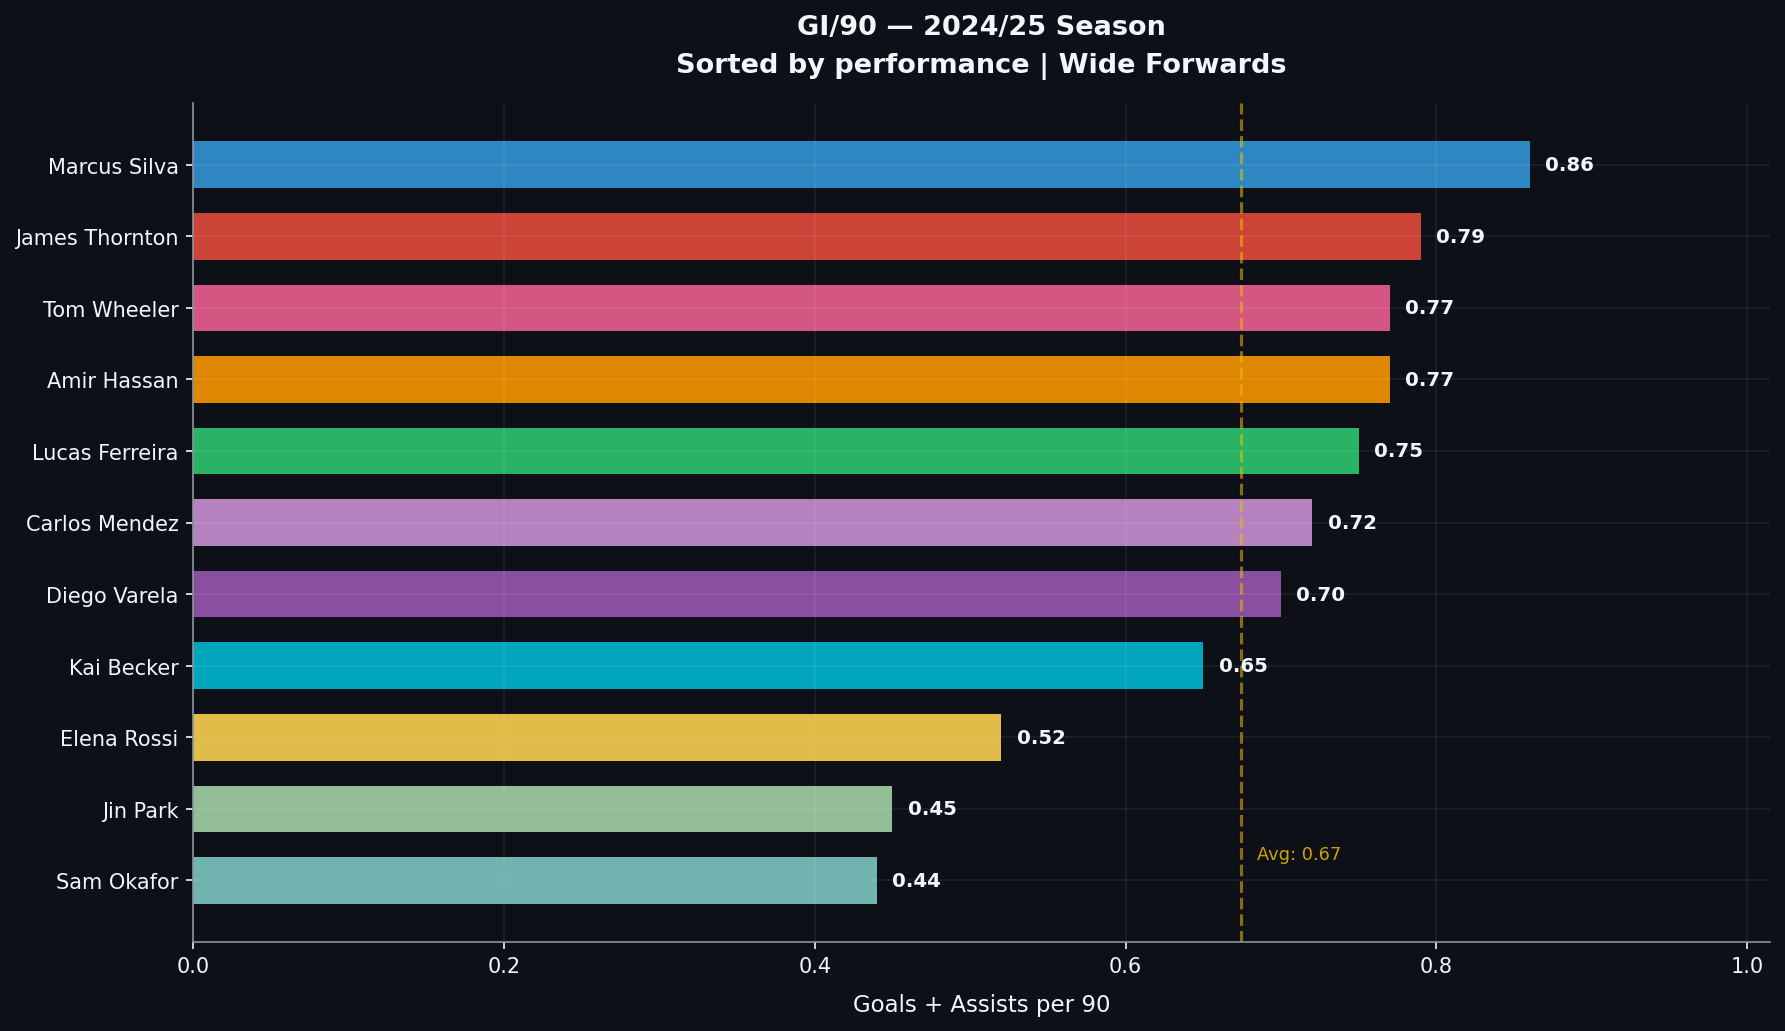

In [1]:
df_sorted = df.sort_values('gi_per90', ascending=True)
bar_colors = [PLAYER_COLORS.get(p, GRAY) for p in df_sorted['player']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)

bars = ax.barh(df_sorted['player'], df_sorted['gi_per90'],
               color=bar_colors, alpha=0.88, height=0.65)

# Value labels at bar ends
for bar, val in zip(bars, df_sorted['gi_per90']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', color=WHITE,
            fontsize=9.5, fontweight='bold')

# Group average line
avg = df_sorted['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)
ax.text(avg + 0.01, 0.3, f'Avg: {avg:.2f}', color=GOLD, fontsize=8.5, alpha=0.85)

style_axis(ax, xlabel='Goals + Assists per 90',
           title='GI/90 — 2024/25 Season',
           subtitle='Sorted by performance | Wide Forwards')
ax.set_xlim(0, df_sorted['gi_per90'].max() * 1.18)
plt.tight_layout()
plt.show()

---
## Part 2 — Tier-Coloured Bars

When the question is 'who is elite vs below average?' rather than 'who is which player?', use tier colours instead of player identity colours. The green/yellow/orange/red gradient does the analytical work before the reader reads a label.

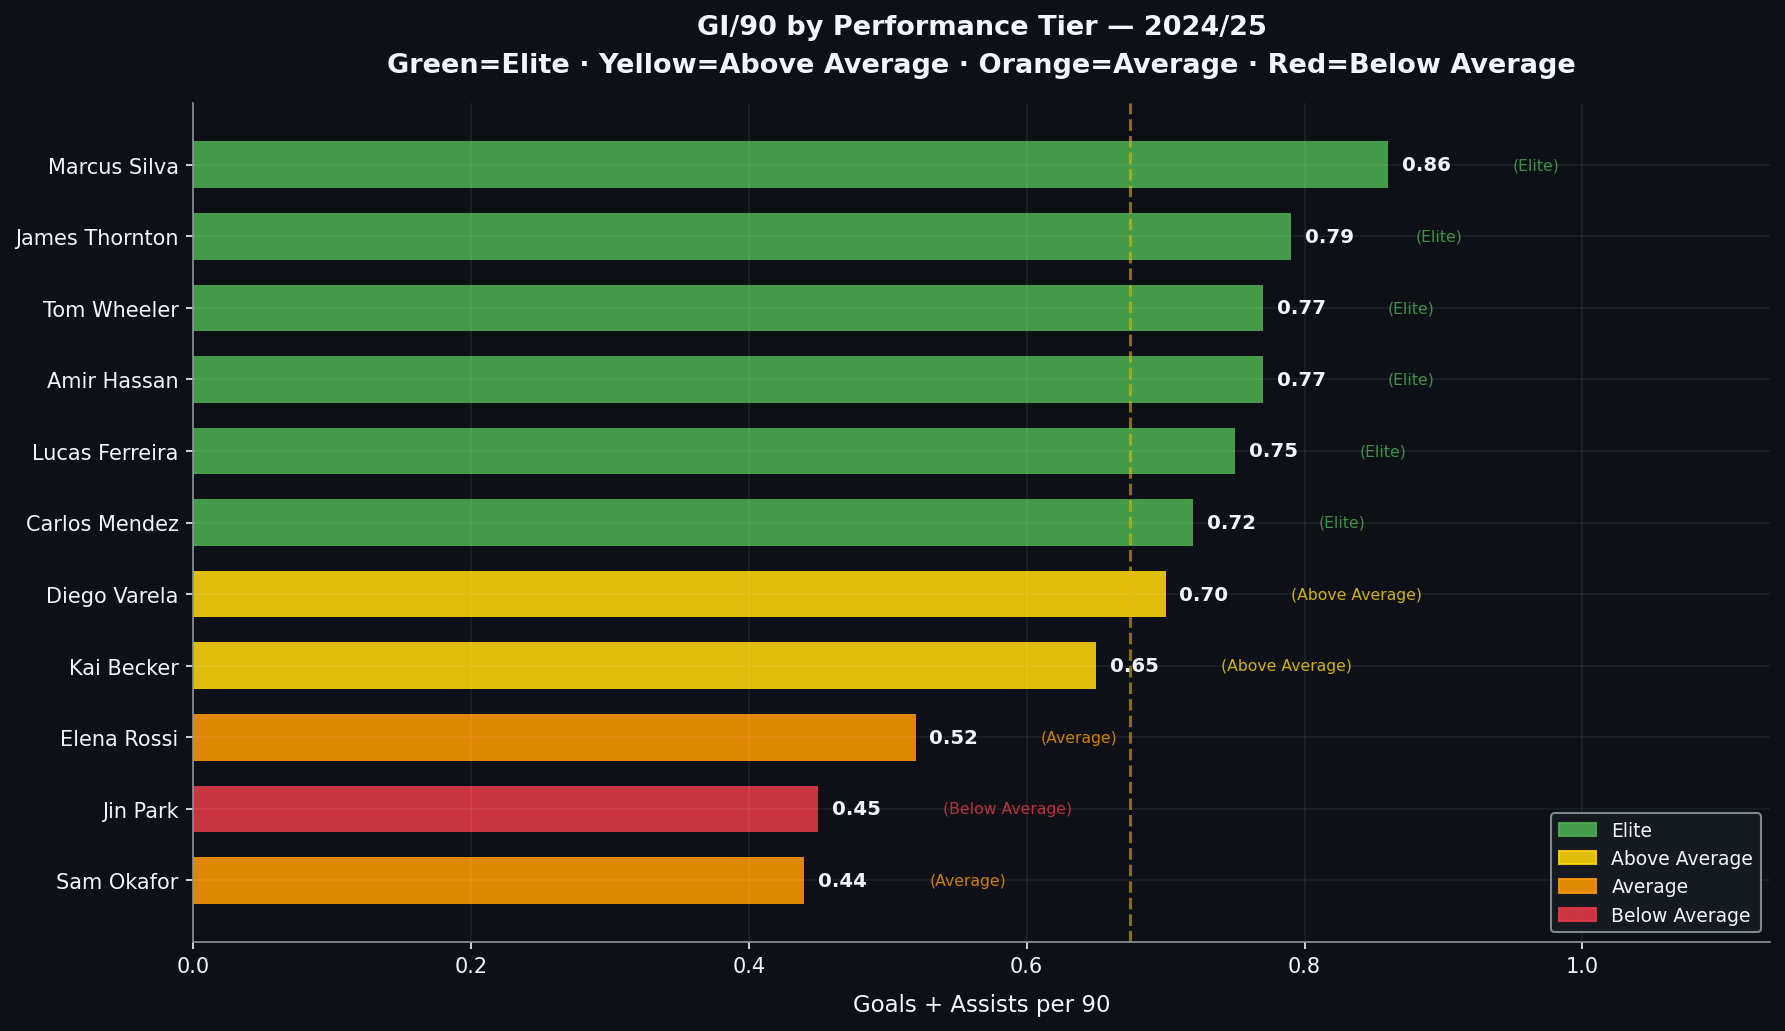

In [1]:
df_sorted = df.sort_values('gi_per90', ascending=True)
tier_colors = [TIER_COLORS[t] for t in df_sorted['tier']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)

bars = ax.barh(df_sorted['player'], df_sorted['gi_per90'],
               color=tier_colors, alpha=0.88, height=0.65)

for bar, val, tier in zip(bars, df_sorted['gi_per90'], df_sorted['tier']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', color=WHITE, fontsize=9.5, fontweight='bold')
    ax.text(bar.get_width() + 0.09, bar.get_y() + bar.get_height()/2,
            f'({tier})', va='center', color=TIER_COLORS[tier], fontsize=7.5, alpha=0.80)

avg = df_sorted['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=t, alpha=0.88)
                  for t, c in TIER_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right',
          facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE,
          fontsize=9, framealpha=0.9)

style_axis(ax, xlabel='Goals + Assists per 90',
           title='GI/90 by Performance Tier — 2024/25',
           subtitle='Green=Elite · Yellow=Above Average · Orange=Average · Red=Below Average')
ax.set_xlim(0, df_sorted['gi_per90'].max() * 1.32)
plt.tight_layout()
plt.show()

---
## Part 3 — Grouped Bar Chart

Two metrics simultaneously — goals per 90 and assists per 90 side by side. This shows immediately who is a scorer vs creator without needing a separate scatter plot.

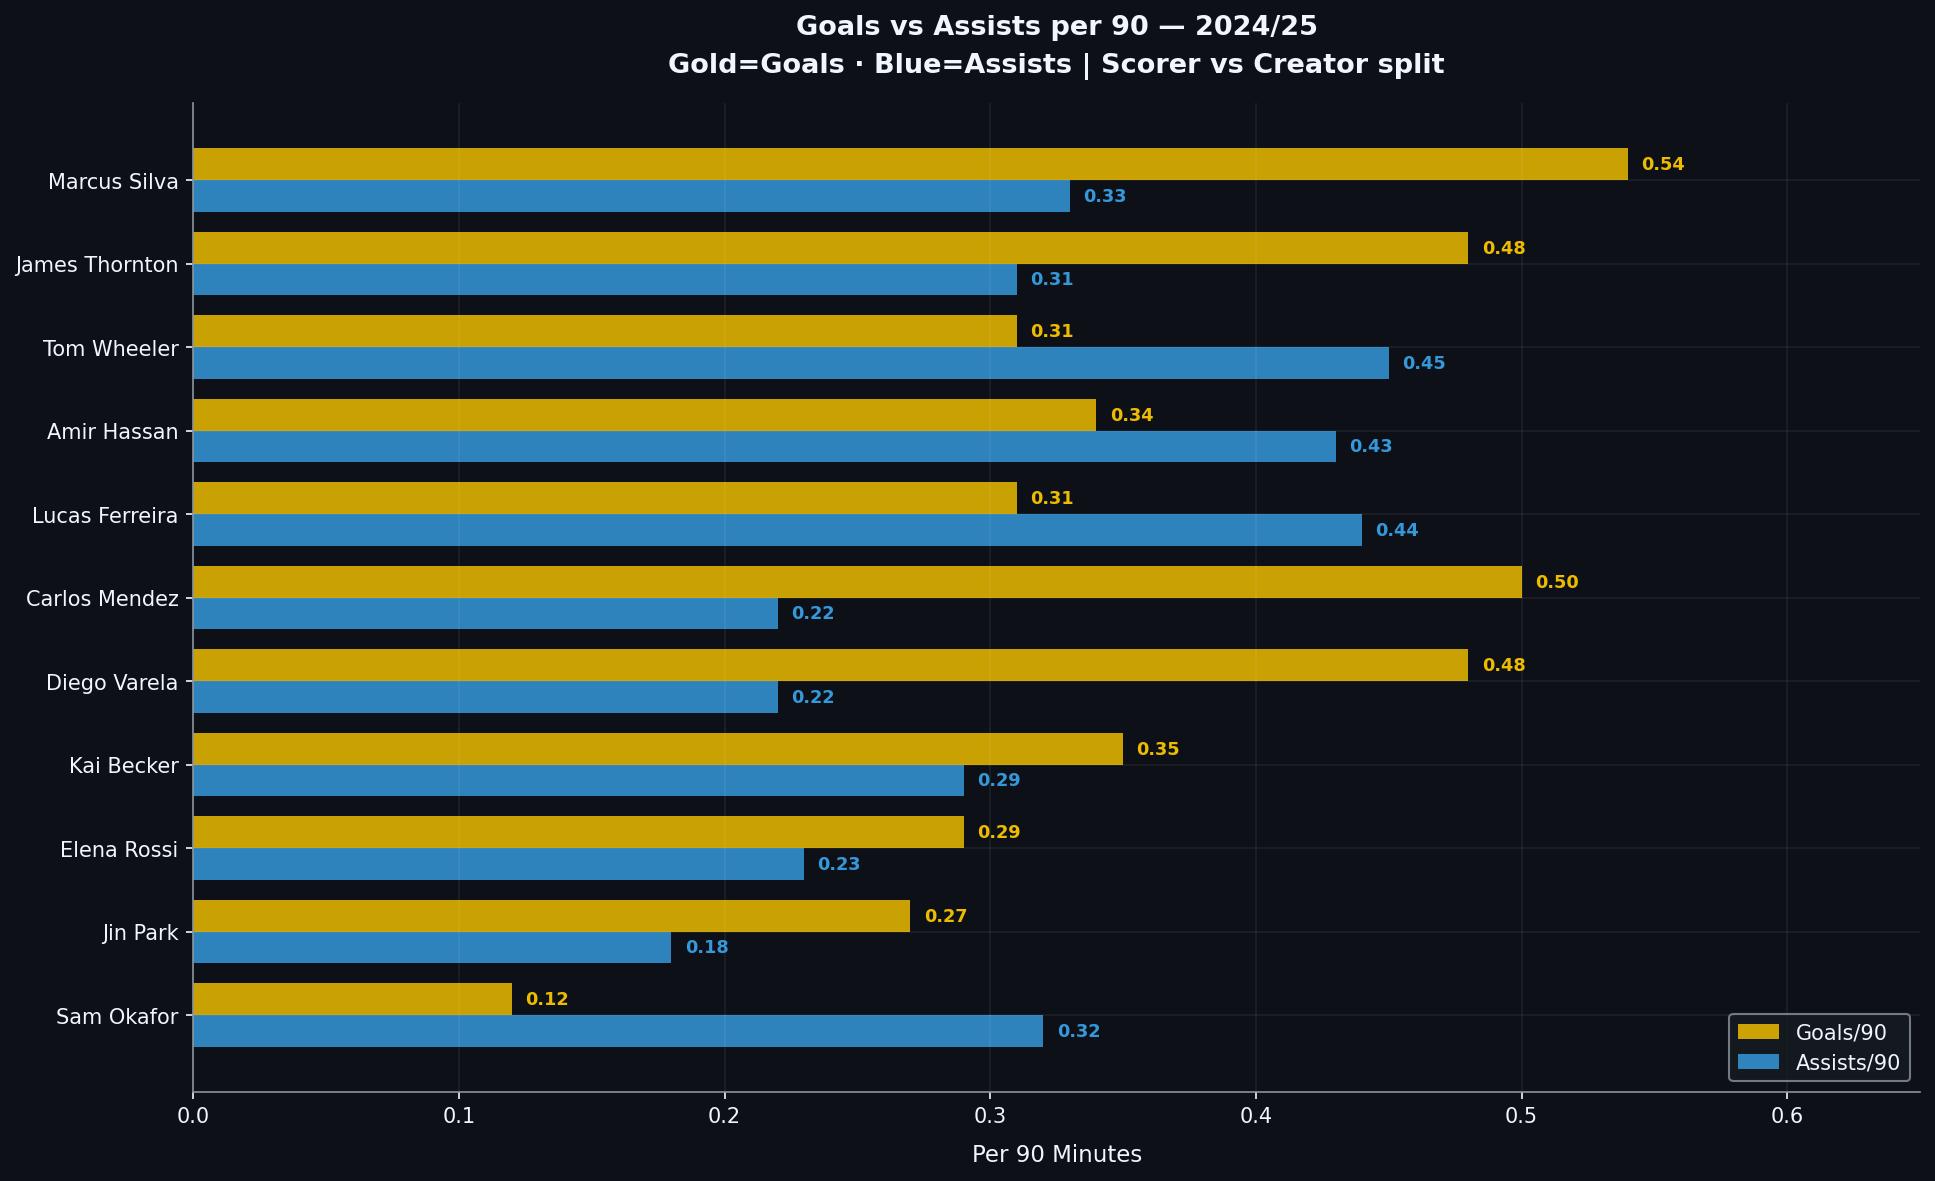

Key insight:
Tom Wheeler and Lucas Ferreira: more assists than goals — pure creators
Diego Varela and Carlos Mendez: more goals than assists — pure finishers
Marcus Silva: goals well above assists — developing scorer


In [1]:
df_sorted = df.sort_values('gi_per90', ascending=True)
y = np.arange(len(df_sorted))
h = 0.38   # bar height for each sub-bar

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG)

# Two bars per player — offset by h/2 above and below the centre
bars_goals   = ax.barh(y + h/2, df_sorted['goals_per90'],   h,
                        color=GOLD,     alpha=0.85, label='Goals/90')
bars_assists = ax.barh(y - h/2, df_sorted['assists_per90'], h,
                        color='#3498DB', alpha=0.85, label='Assists/90')

# Value labels
for bar, val in zip(bars_goals, df_sorted['goals_per90']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', color=GOLD, fontsize=8.5, fontweight='bold')
for bar, val in zip(bars_assists, df_sorted['assists_per90']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', color='#3498DB', fontsize=8.5, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(df_sorted['player'], color=WHITE, fontsize=10)
ax.legend(loc='lower right', facecolor=BG3, edgecolor=GRAY,
          labelcolor=WHITE, fontsize=10)

style_axis(ax, xlabel='Per 90 Minutes',
           title='Goals vs Assists per 90 — 2024/25',
           subtitle='Gold=Goals · Blue=Assists | Scorer vs Creator split')
ax.set_xlim(0, 0.65)
plt.tight_layout()
plt.show()

print("Key insight:")
print("Tom Wheeler and Lucas Ferreira: more assists than goals — pure creators")
print("Diego Varela and Carlos Mendez: more goals than assists — pure finishers")
print("Marcus Silva: goals well above assists — developing scorer")

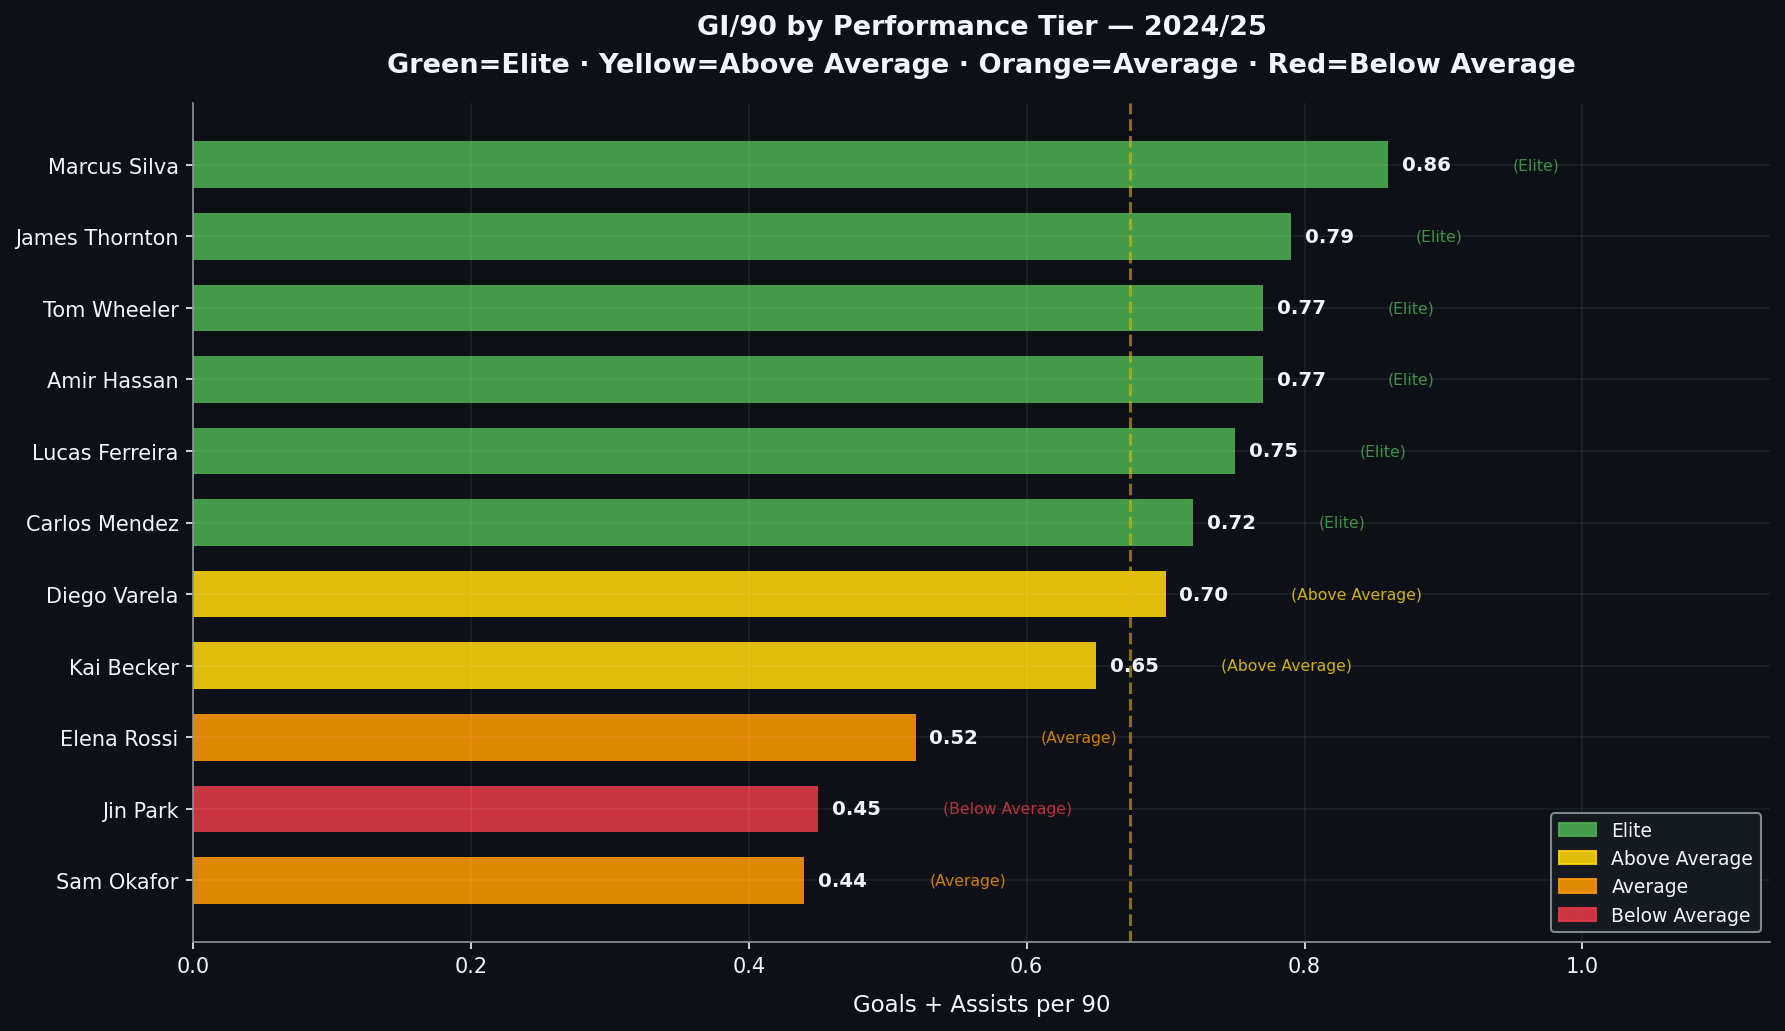

✓ build_bar_chart() template working. Change metric, color_by, title — done.


In [1]:
# THE REUSABLE TEMPLATE — build_bar_chart()
def build_bar_chart(df, metric, sort_ascending=True,
                    color_by='player', title='', subtitle='',
                    figsize=(12, 7)):
    """
    Build a publication-ready horizontal bar chart.

    Parameters
    ----------
    df             : DataFrame
    metric         : str — column to plot
    sort_ascending : bool — True puts lowest at top
    color_by       : 'player' or 'tier'
    title, subtitle: str
    figsize        : tuple

    Returns: fig, ax
    """
    df_sorted = df.sort_values(metric, ascending=sort_ascending)

    if color_by == 'tier' and 'tier' in df.columns:
        colors = [TIER_COLORS.get(t, GRAY) for t in df_sorted['tier']]
    else:
        colors = [PLAYER_COLORS.get(p, GRAY) for p in df_sorted['player']]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)

    bars = ax.barh(df_sorted['player'], df_sorted[metric],
                   color=colors, alpha=0.88, height=0.65)

    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() + df_sorted[metric].max()*0.012,
                bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center',
                color=WHITE, fontsize=9.5, fontweight='bold')

    avg = df_sorted[metric].mean()
    ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)
    ax.text(avg + df_sorted[metric].max()*0.012, 0.3,
            f'Avg: {avg:.2f}', color=GOLD, fontsize=8.5, alpha=0.85)

    style_axis(ax, xlabel=metric.replace('_',' ').title(),
               title=title, subtitle=subtitle)
    ax.set_xlim(0, df_sorted[metric].max() * 1.20)
    return fig, ax

# Test it
fig, ax = build_bar_chart(df, metric='pass_accuracy_pct',
                           color_by='tier',
                           title='Pass Accuracy % — 2024/25',
                           subtitle='Who is most reliable in possession?')
plt.tight_layout()
plt.show()
print("✓ build_bar_chart() template working. Change metric, color_by, title — done.")

---
## Exercises

### Exercise 1 (Easy) — Change the Metric
Call `build_bar_chart()` with `metric='shots_per90'`. Which players shoot most?
Is it the same ranking as GI/90?

### Exercise 2 (Medium) — Add a Target Line
After calling `build_bar_chart()`, add a second vertical line showing a target
threshold — for example, 0.50 GI/90 as a "quality starter" benchmark:
```python
ax.axvline(x=0.50, color='#00BCD4', linestyle=':', alpha=0.6, linewidth=1.2)
ax.text(0.50, 0.1, 'Starter threshold', color='#00BCD4', fontsize=8)
```

### Exercise 3 (Hard) — Diverging Bar Chart
A diverging bar chart shows values that go both positive and negative from
a central baseline. Build one showing `overperformance = goals_per90 - xg_per90`.
Bars going right = overperforming. Bars going left = underperforming.

---
## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| Horizontal bars | Better for long labels |
| Average reference line | `ax.axvline()` — the most useful single annotation |
| Value labels | `ax.text()` at bar end |
| Tier colouring | Colour by meaning when ranking a group |
| Grouped bars | Two metrics simultaneously — offset `y + h/2`, `y - h/2` |
| `build_bar_chart()` | Template — change metric and colour strategy |

---
## Up Next — Chapter 7: Radar Charts

*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*